# Issue #554: coarse-to-fine regridding coverage

`interpolate_coarse_to_fine_grid` left NaN holes on every GCM grid that is not
CESM2-WACCM's.

| name | padding | kernel |
|------|---------|--------|
| `main` | right-only longitude wrap, no pole padding | `slinear` |
| `branch` | `xarray-regrid`'s `format_for_regrid`: zonal-mean pole rows, both lon seams | `slinear` |


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from srm.datasets import catalog
from srm.downscaling_utils import interpolate_coarse_to_fine_grid

VARIABLE = "rsds"
SCENARIO = "ssp245"
GCMS = ["CESM2-WACCM", "MIROC-ES2H", "UKESM"]

In [2]:
def interp_main(da_coarse, da_fine, axis_order=("lon", "lat")):
    """main's implementation: right-only wrap, slinear, no latitude padding."""
    if not da_coarse.indexes["lon"].is_monotonic_increasing:
        da_coarse = da_coarse.sortby("lon")

    lon = da_coarse["lon"]
    lon_vals = lon.values
    dlon = np.median(np.diff(lon_vals))
    spans_globe = lon_vals.size > 1 and (lon_vals[-1] - lon_vals[0]) >= 360.0 - 1.5 * dlon

    if spans_globe:
        right = da_coarse.isel(lon=[0]).assign_coords(lon=lon.isel(lon=[0]) + 360)
        da_to_interp = xr.concat([da_coarse, right], dim="lon")
    else:
        da_to_interp = da_coarse

    coords = {ax: da_fine[ax] for ax in axis_order}
    return da_to_interp.interp(coords=coords, method="slinear").astype(da_coarse.dtype)


def west_of_first_coarse_lon(n, c):
    """Fine cells strictly west of the coarse grid's first longitude - the seam gap."""
    return n.sel(lon=n["lon"][n["lon"].values < float(c["lon"].values[0])])


fine = catalog.get("ERA5").to_xarray()[VARIABLE]


def coarse_slice(gcm):
    """One 2-D (lat, lon) field: first ensemble member, first timestep."""
    da = catalog.get(gcm).to_xarray()[SCENARIO][VARIABLE]
    for dim in da.dims:
        if dim not in ("lat", "lon", "time"):
            da = da.isel({dim: 0}, drop=True)
    return da.isel(time=0, drop=True).load()


coarse = {gcm: coarse_slice(gcm) for gcm in GCMS}
old = {gcm: interp_main(c, fine) for gcm, c in coarse.items()}
new = {gcm: interpolate_coarse_to_fine_grid(c, fine) for gcm, c in coarse.items()}

print(
    f"fine grid: lat {fine.lat.values[0]}..{fine.lat.values[-1]} ({fine.sizes['lat']})  "
    f"lon {fine.lon.values[0]}..{fine.lon.values[-1]} ({fine.sizes['lon']})"
)
for gcm, c in coarse.items():
    lat, lon = c["lat"].values, c["lon"].values
    print(
        f"{gcm:13s} lat {lat[0]:8.3f}..{lat[-1]:7.3f} ({lat.size:3d})   "
        f"lon {lon[0]:9.4f}..{lon[-1]:8.4f} ({lon.size:3d})"
    )

fine grid: lat -90.0..90.0 (721)  lon -180.0..179.75 (1440)
CESM2-WACCM   lat  -90.000.. 90.000 (192)   lon -180.0000..178.7500 (288)
MIROC-ES2H    lat  -88.928.. 88.928 (128)   lon -180.0000..178.5938 (256)
UKESM         lat  -89.375.. 89.375 (144)   lon -179.0625..179.0625 (192)


## 1. comparing old method with update

Zoomed to the two affected regions. `main`'s panels carry the polar cap and the west-seam
strip; the branch's are complete.

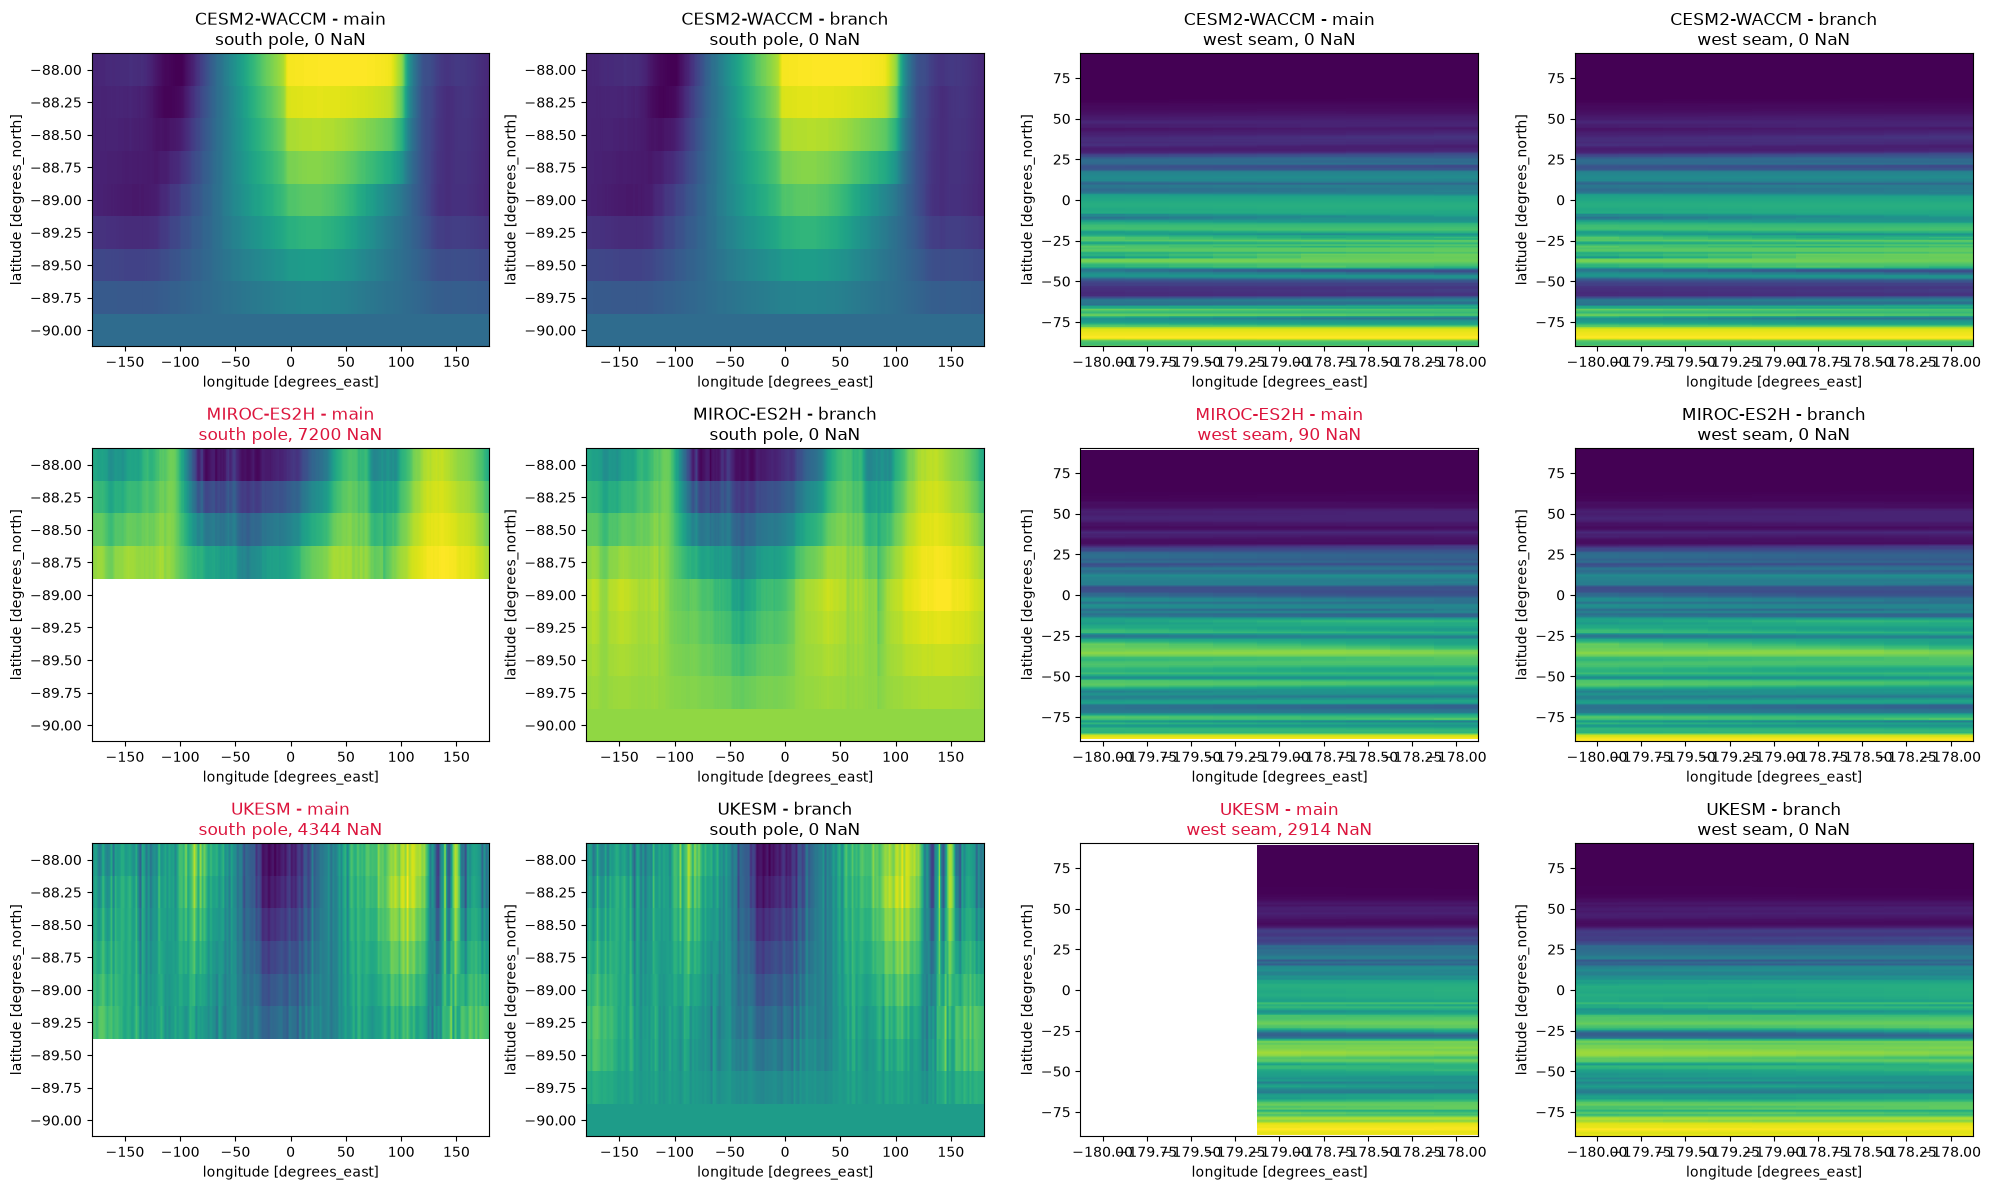

In [3]:
fig, axes = plt.subplots(len(GCMS), 4, figsize=(20, 4 * len(GCMS)))
for row, gcm in enumerate(GCMS):
    panels = [
        (old[gcm], "main", dict(lat=slice(-90, -88)), "south pole"),
        (new[gcm], "branch", dict(lat=slice(-90, -88)), "south pole"),
        (old[gcm], "main", dict(lon=slice(-180, -178)), "west seam"),
        (new[gcm], "branch", dict(lon=slice(-180, -178)), "west seam"),
    ]
    for col, (da, label, sel, region) in enumerate(panels):
        ax = axes[row, col]
        da.sel(**sel).plot(ax=ax, add_colorbar=False)
        n_nan = int(da.sel(**sel).isnull().sum())
        ax.set_title(
            f"{gcm} - {label}\n{region}, {n_nan} NaN", color="crimson" if n_nan else "black"
        )
plt.tight_layout()
plt.show()

## 3. What changed, and what did not

Coverage should be gained and never lost. Values should be untouched wherever `main`
already produced a number: both sides run the same `slinear` kernel, and padding rows
added outside the coarse grid's own extent cannot move a piecewise-linear interpolant
strictly inside it.

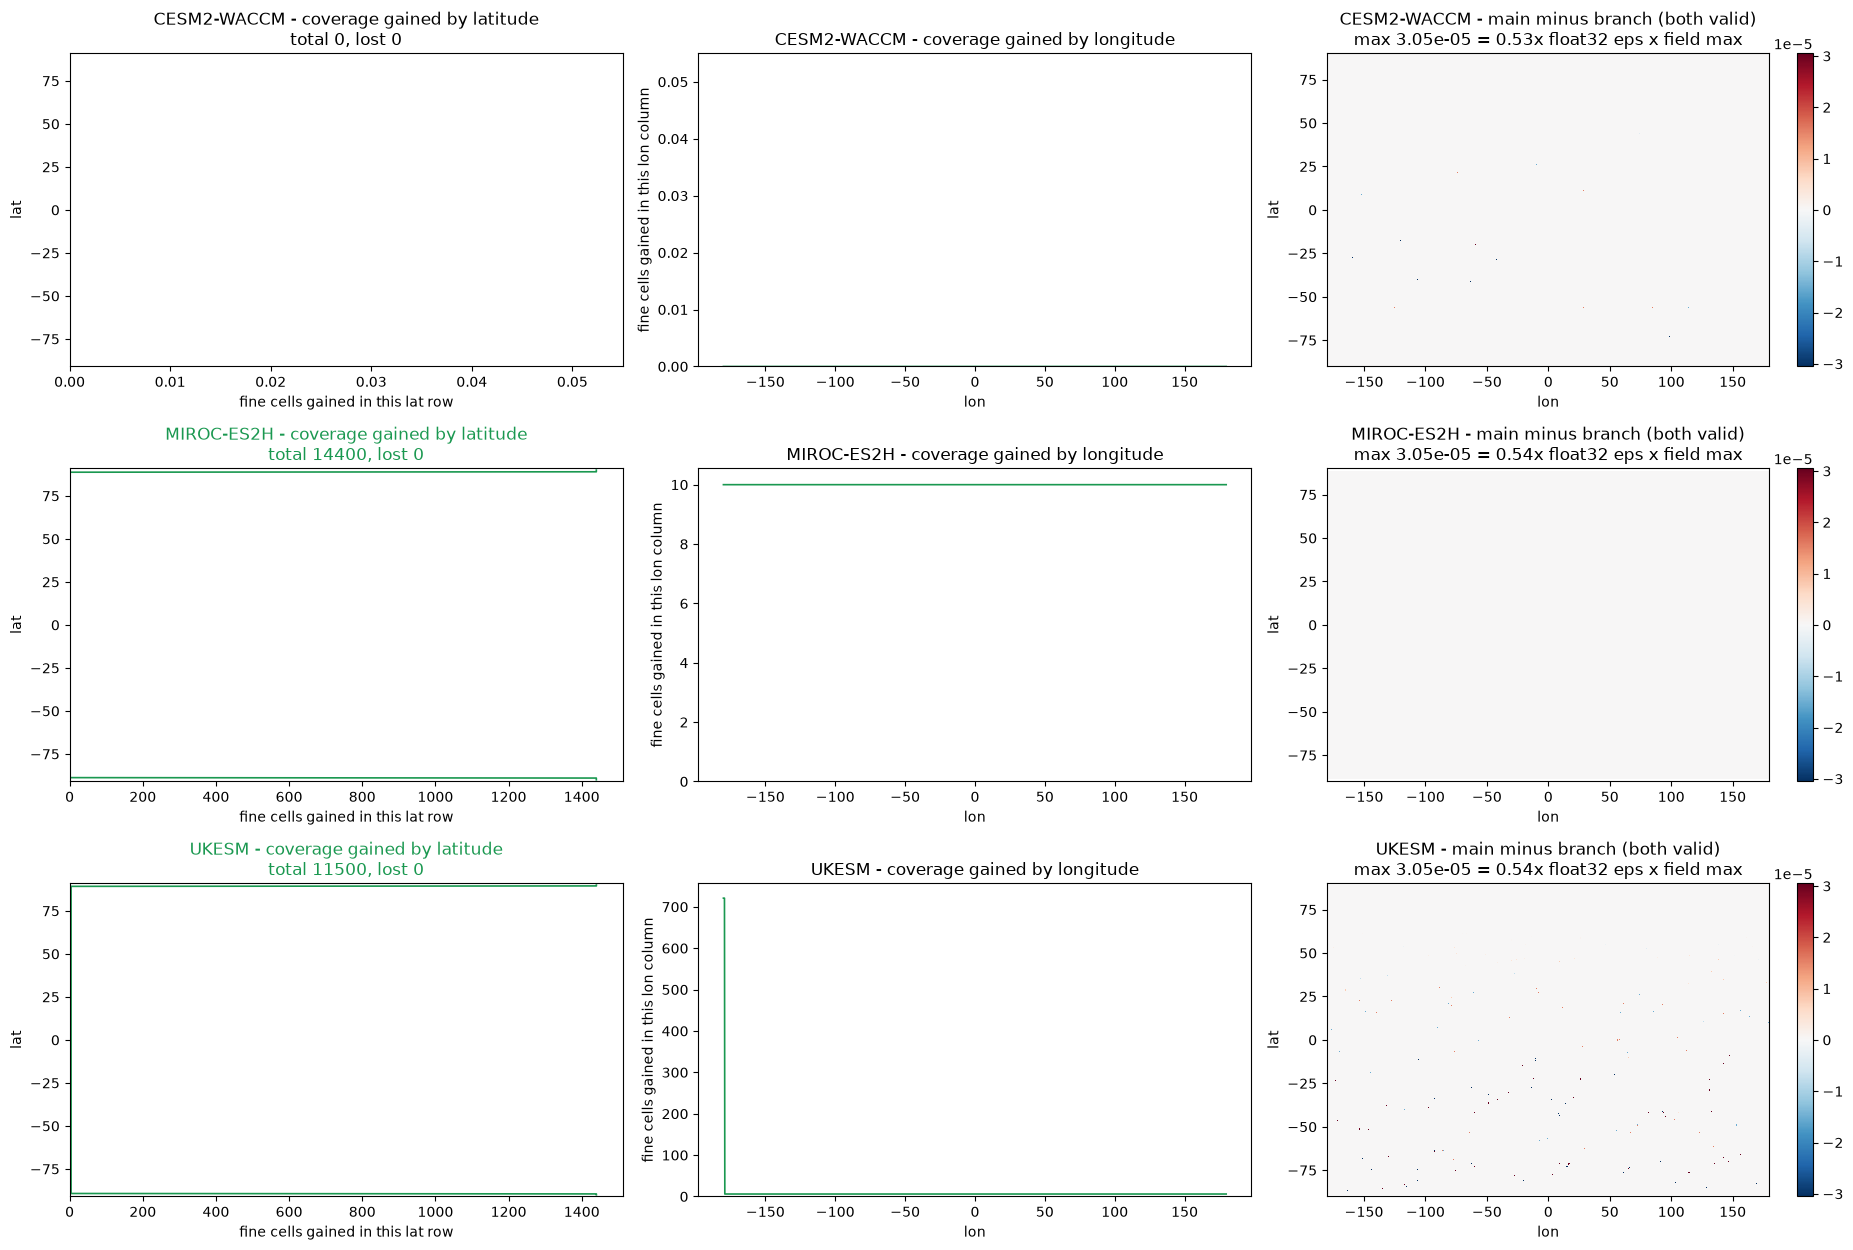

In [4]:
fig, axes = plt.subplots(len(GCMS), 3, figsize=(19, 4.2 * len(GCMS)))
for row, gcm in enumerate(GCMS):
    o, n = old[gcm], new[gcm]
    gained = o.isnull() & ~n.isnull()
    n_gained = int(gained.sum())
    n_lost = int((~o.isnull() & n.isnull()).sum())

    ax = axes[row, 0]
    ax.plot(gained.sum("lon"), gained.lat, lw=1.2, color="#1a9850")
    ax.set_xlabel("fine cells gained in this lat row")
    ax.set_ylabel("lat")
    ax.set_ylim(-91, 91)
    ax.set_xlim(left=0)  # so a no-change panel reads as zero, not as a degenerate axis
    ax.set_title(
        f"{gcm} - coverage gained by latitude\ntotal {n_gained}, lost {n_lost}",
        color="#1a9850" if n_gained and not n_lost else "black",
    )

    ax = axes[row, 1]
    ax.plot(gained.lon, gained.sum("lat"), lw=1.2, color="#1a9850")
    ax.set_xlabel("lon")
    ax.set_ylabel("fine cells gained in this lon column")
    ax.set_ylim(bottom=0)
    ax.set_title(f"{gcm} - coverage gained by longitude")

    both = (~o.isnull()) & (~n.isnull())
    diff = (o - n).where(both)
    lim = float(np.nanmax(np.abs(diff.values))) or 1e-12
    scale = float(np.abs(o.values[both.values]).max()) or 1.0
    eps = scale * np.finfo(np.float32).eps

    ax = axes[row, 2]
    m = ax.pcolormesh(diff.lon, diff.lat, diff.values, cmap="RdBu_r", vmin=-lim, vmax=lim)
    fig.colorbar(m, ax=ax)
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    ax.set_title(
        f"{gcm} - main minus branch (both valid)\n"
        f"max {lim:.2e} = {lim / eps:.2f}x float32 eps x field max"
    )

plt.tight_layout()
plt.show()